In [1]:
import pandas as pd
import pickle

with open('/Users/wfr5091/Downloads/df_sample_organized.pkl', 'rb') as fid:
    df = pickle.load(fid)
print(df.shape)
print(df.columns)

(29665, 5)
Index(['A_scans', 'File_tag', 'Tape_no', 'Manual Stud', 'Updated wall_type'], dtype='object')


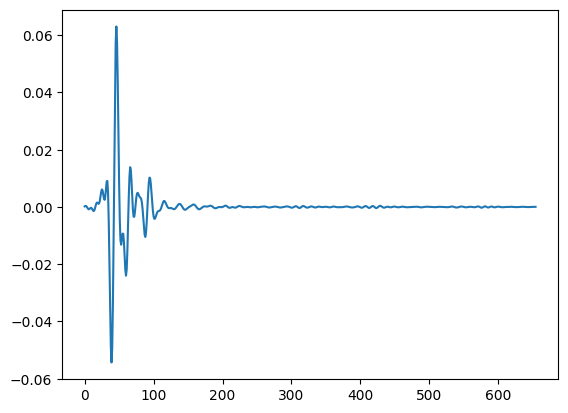

In [2]:
import matplotlib.pyplot as plt

plt.plot(df['A_scans'].values[3])

In [5]:
for tape_no, sub_df in df.groupby('Tape_no'):
    values = sub_df['Updated wall_type'].unique()
    if len(values) < 2:
        continue
    print(tape_no, values)

2 ['cement_dirt' 'cement' 'transition']
5 ['cement' 'transition' 'cement_dirt']
13 ['cement' 'transition' 'cement_dirt']
15 ['transition' 'cement']


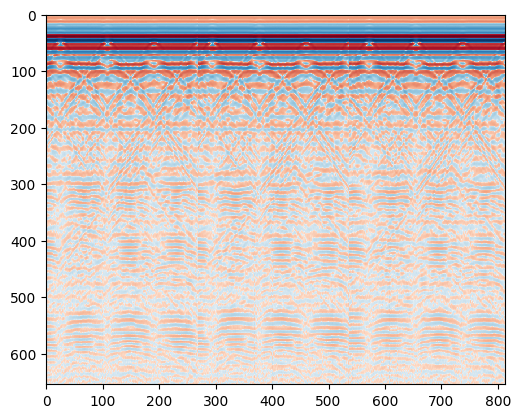

In [6]:
import numpy as np

df_tape2 = df.loc[df.loc[:, 'Tape_no'] == 2]
bscan = np.vstack(df_tape2['A_scans'].values).T
bscan_gain = np.sign(bscan)*np.abs(bscan)**0.20
plt.imshow(bscan_gain, cmap='RdBu', interpolation='none')

['cement' 'cement_dirt' 'transition']


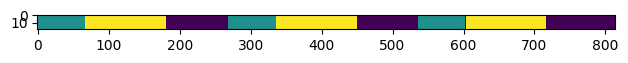

In [7]:
vals, wall_id = np.unique(df_tape2['Updated wall_type'], return_inverse=True)
print(vals)
plt.imshow(wall_id.reshape(1, -1) * np.ones([20, len(wall_id)]), interpolation='none')
plt.tight_layout()
# plt.yticks(range(3), vals)

(-0.5, 813.5, 0.5, -0.5)

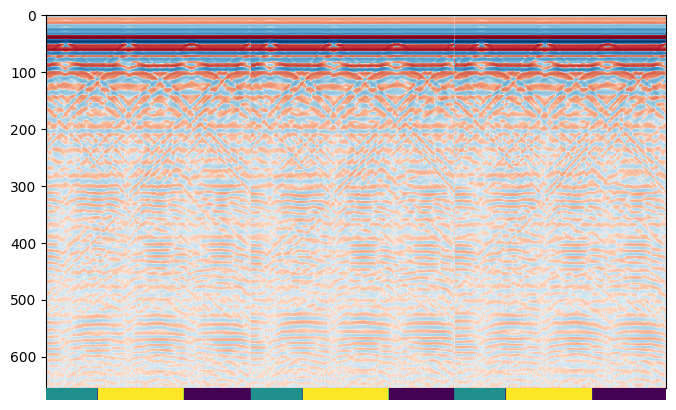

In [8]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(8, 5.0), gridspec_kw={'height_ratios': [30, 1]})
fig.subplots_adjust(hspace=0)
axes[0].imshow(bscan_gain, cmap='RdBu', aspect='auto', interpolation='none')
axes[1].imshow(wall_id.reshape(1, -1), aspect='auto')
axes[1].axis('off')

In [10]:
from sklearn import decomposition

svd = decomposition.TruncatedSVD(n_components=2, random_state=0)
z = svd.fit_transform(bscan.T)
print(z.shape)

(814, 2)


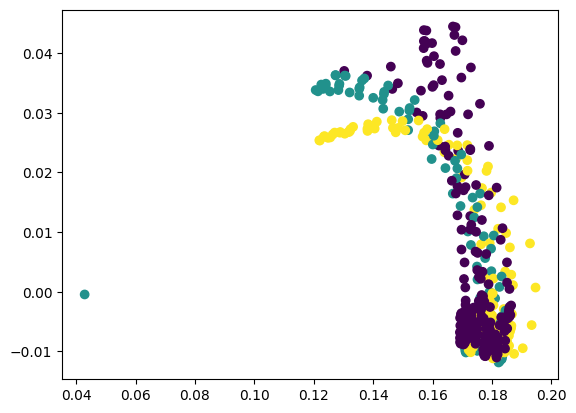

In [12]:
plt.scatter(z[:, 0], z[:, 1], c=wall_id)

(-0.5, 813.5, 0.5, -0.5)

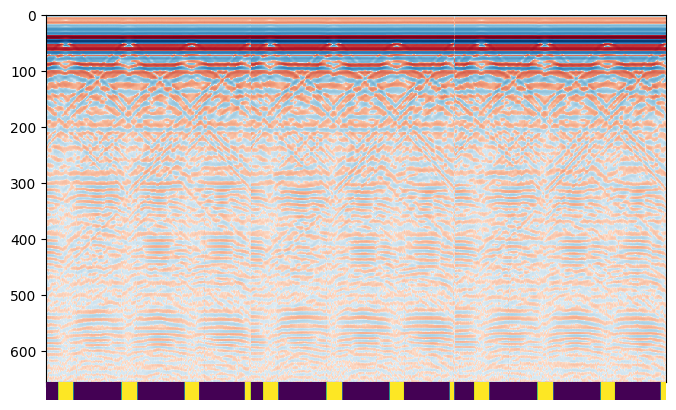

In [22]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(8, 5.0), gridspec_kw={'height_ratios': [20, 1]})
fig.subplots_adjust(hspace=0)
axes[0].imshow(bscan_gain, cmap='RdBu', aspect='auto', interpolation='none')
axes[1].imshow((z[:, 1] > 0).reshape(1, -1), aspect='auto')
axes[1].axis('off')

In [28]:
stud_id = (z[:, 1] > 0)

In [23]:
import sparsenn
from torch.nn import functional as F


class RegularizedMLPClassifier(sparsenn.RegularizedMLP):
    def forward(self, x):
        for i, layer in enumerate(self.layers[:-1]):
            x = self.activation(layer(x))
        x = self.layers[-1](x)
        return F.sigmoid(x)

In [47]:
import torch

has_label = wall_id != 2

_, scan_id = np.unique(df_tape2['File_tag'], return_inverse=True)
is_train = np.logical_and(scan_id == 0, has_label)
is_valid = np.logical_and(scan_id > 0, has_label)

x_train = bscan[:, is_train].T
y_train = wall_id[is_train]
# y_train = stud_id[is_train]

x_train = torch.tensor(x_train).float()
y_train = torch.tensor(y_train).long()

x_valid = bscan[:, is_valid].T
y_valid = wall_id[is_valid]
# y_valid = stud_id[is_valid]

x_valid = torch.tensor(x_valid).float()
y_valid = torch.tensor(y_valid).long()

In [48]:
from torch import nn, optim
import sparsenn
from sparsenn import pareto

input_dim = x_train.shape[1]
hidden_dim = (8, 8, )
output_dim = 2 # y_train.shape[1]

model = RegularizedMLPClassifier(input_dim, hidden_dim, output_dim)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [49]:
max_epochs = int(1e5)
lmbda_reg = 1e-4 #  * 2**12
model.train()
for epoch in range(max_epochs):
    optimizer.zero_grad()
    outputs = model(x_train)
    loss = criterion(outputs, y_train)
    reg_loss = model.regularization_loss()
    total_loss = loss + lmbda_reg * reg_loss
    total_loss.backward()
    optimizer.step()
    if (epoch+1) % 100 == 0:
        classes = np.argmax(outputs.detach().cpu().numpy(), axis=1)
        misses = np.sum(classes ^ y_train.numpy())
        train_acc = 1 - misses / len(y_train)
        with torch.no_grad():
            classes = np.argmax(model(x_valid).cpu().numpy(), axis=1)
            misses = np.sum(classes ^ y_valid.numpy())
            valid_acc = 1 - misses / len(y_valid)
        print(f'Epoch {epoch+1}, CELoss: {loss.item():.4f}, Tr Acc: {train_acc:.3f}, Val Acc: {valid_acc:.3f}, L0R: {reg_loss.item():.2f}')        

Epoch 100, CELoss: 0.6850, Tr Acc: 0.568, Val Acc: 0.594, L0R: 4348.43
Epoch 200, CELoss: 0.6839, Tr Acc: 0.568, Val Acc: 0.594, L0R: 4263.28
Epoch 300, CELoss: 0.6849, Tr Acc: 0.568, Val Acc: 0.594, L0R: 4169.99
Epoch 400, CELoss: 0.6838, Tr Acc: 0.568, Val Acc: 0.594, L0R: 4068.24
Epoch 500, CELoss: 0.6837, Tr Acc: 0.568, Val Acc: 0.594, L0R: 3958.03
Epoch 600, CELoss: 0.6835, Tr Acc: 0.568, Val Acc: 0.594, L0R: 3839.54
Epoch 700, CELoss: 0.6836, Tr Acc: 0.568, Val Acc: 0.594, L0R: 3713.17
Epoch 800, CELoss: 0.6837, Tr Acc: 0.568, Val Acc: 0.594, L0R: 3579.69
Epoch 900, CELoss: 0.6837, Tr Acc: 0.568, Val Acc: 0.594, L0R: 3440.03
Epoch 1000, CELoss: 0.6831, Tr Acc: 0.568, Val Acc: 0.594, L0R: 3295.46
Epoch 1100, CELoss: 0.6825, Tr Acc: 0.568, Val Acc: 0.594, L0R: 3147.44
Epoch 1200, CELoss: 0.6824, Tr Acc: 0.568, Val Acc: 0.594, L0R: 2997.63
Epoch 1300, CELoss: 0.6811, Tr Acc: 0.568, Val Acc: 0.594, L0R: 2847.88
Epoch 1400, CELoss: 0.6793, Tr Acc: 0.568, Val Acc: 0.594, L0R: 2699.88
E

In [50]:
from sparsenn import viz

model.eval()

# Render the optimized architecture 
g = viz.gated_connections_graph(model)

layers = list(set([it.split("_")[0] for it in sorted(g.nodes)]))
paths, valid_nodes = sparsenn.viz.find_paths_nodes(g, True)

height = {node: [] for node in valid_nodes}
for n in valid_nodes:
    for p in paths:
        if n not in p:
            continue
        if p[-1].startswith('output'):
            height[n].append(float(p[-1].split('_')[-1]))

for n in valid_nodes:
    # convert from list to mean
    height[n] = np.mean(height[n])

for node in list(g.nodes):
    if node not in valid_nodes:
        g.remove_node(node)

print(len(g.nodes))

useful_inputs = [int(it.strip('input_')) for it in list(g.nodes) if it.startswith('input_')]
print(len(useful_inputs))
all_inputs = np.zeros(bscan.shape[0], dtype=bool)
all_inputs[useful_inputs] = True

52
41


In [51]:
input_weights = np.array([(int(i.strip('input_')), d['weight']) for i, j, d in g.edges(data=True) if i.startswith('input_')])

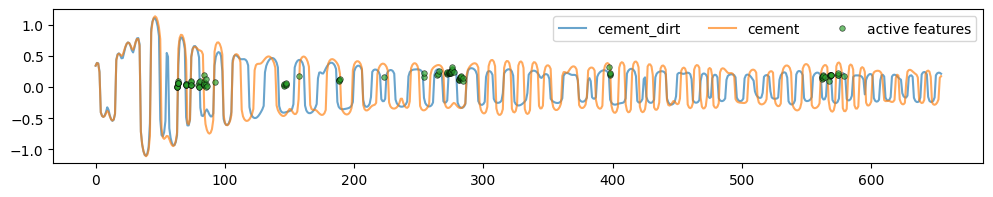

In [52]:
fig, ax = plt.subplots(figsize=(12, 2))
ax.plot(bscan_gain[:, 30]*2, alpha=0.67, label='cement_dirt')
ax.plot(bscan_gain[:, 230]*2, alpha=0.67, label='cement')
ax.plot(input_weights[:, 0], np.abs(input_weights[:, 1])*0.01, 'o', alpha=0.67, ms=4, mec='k', mew=0.5, label='active features')
ax.legend(ncols=3)

(-0.5, 813.5, 0.5, -0.5)

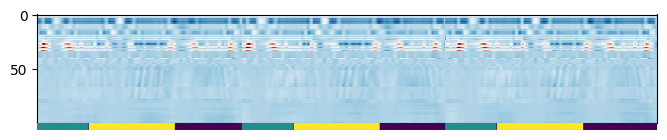

In [53]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(8, 1.5), gridspec_kw={'height_ratios': [15, 1]})
fig.subplots_adjust(hspace=0)
bscan_low_gain = bscan # np.sign(bscan)*np.abs(bscan)**0.67
internal_repr = bscan[input_weights[:, 0].astype(int)] * input_weights[:, [1]]
axes[0].imshow(internal_repr, cmap='RdBu', aspect='auto', interpolation='none')
axes[1].imshow(wall_id.reshape(1, -1), aspect='auto')
axes[1].axis('off')

[0.47876969 0.18191859 0.08998788 0.04285892 0.0400406 ]


(-0.5, 813.5, 0.5, -0.5)

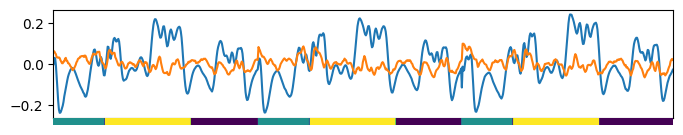

In [578]:
internal_repr = bscan[input_weights[:, 0].astype(int)] * input_weights[:, [1]]
z = pca.fit_transform(internal_repr.T)
print(pca.explained_variance_ratio_)

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(8, 1.5), gridspec_kw={'height_ratios': [15, 1]})
fig.subplots_adjust(hspace=0)
axes[0].plot(z[:, 0])
axes[0].plot(z[:, 4])
axes[1].imshow(wall_id.reshape(1, -1), aspect='auto')
axes[1].axis('off')

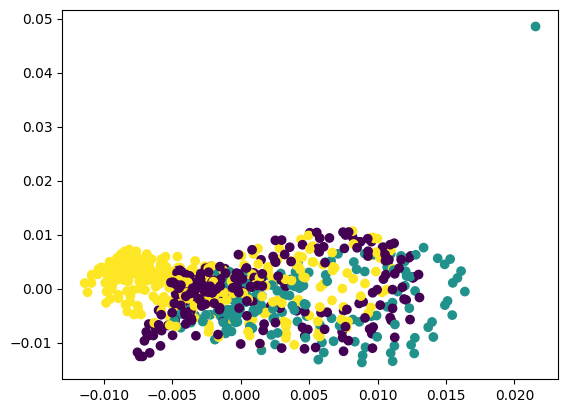

In [590]:
z = pca.fit_transform(bscan_low_gain.T)
plt.scatter(z[:, 2], z[:, 3], c=wall_id)

(-0.5, 813.5, 0.5, -0.5)

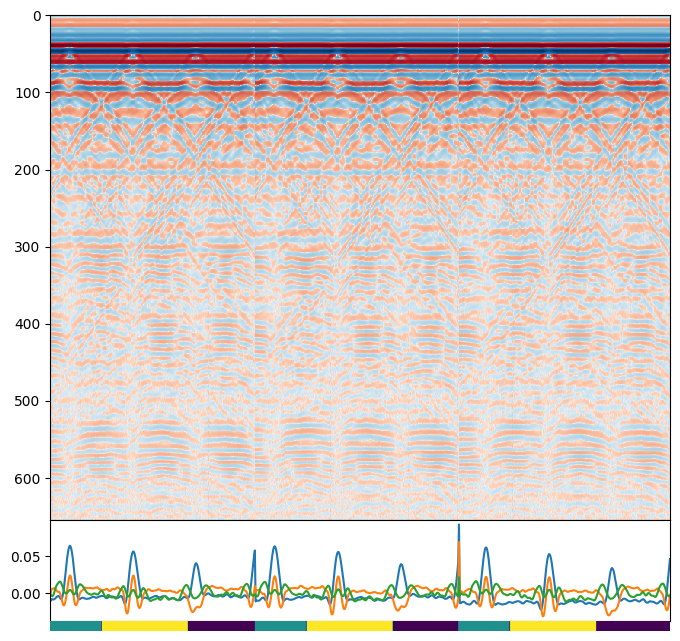

In [597]:
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(8, 8), gridspec_kw={'height_ratios': [50, 10, 1]})
fig.subplots_adjust(hspace=0)
axes[0].imshow(bscan_gain, cmap='RdBu', aspect='auto', interpolation='none')
axes[1].plot(z[:, 0])
axes[1].plot(z[:, 1])
axes[1].plot(z[:, 2])
axes[2].imshow(wall_id.reshape(1, -1), aspect='auto')
axes[2].axis('off')

(-0.5, 813.5, 0.5, -0.5)

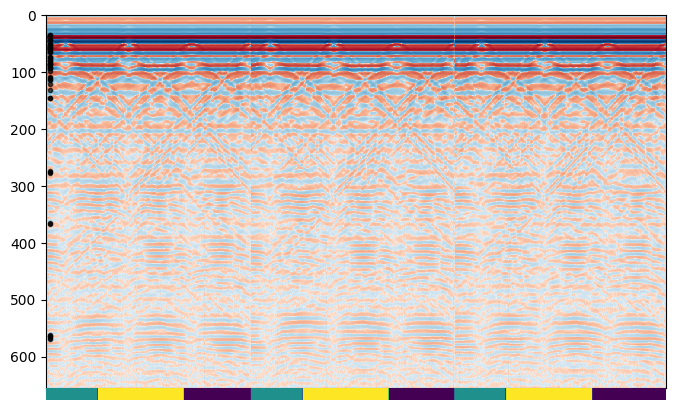

In [560]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(8, 5.0), gridspec_kw={'height_ratios': [30, 1]})
fig.subplots_adjust(hspace=0)
axes[0].imshow(bscan_gain, cmap='RdBu', aspect='auto', interpolation='none')
axes[0].plot(np.ones_like(useful_inputs)*5, useful_inputs, 'o', color='k', alpha=0.67, ms=3)
axes[1].imshow(wall_id.reshape(1, -1), aspect='auto')
axes[1].axis('off')

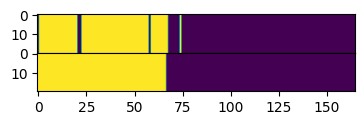

In [58]:
with torch.no_grad():
    outputs = model(x_valid).cpu().numpy()
    classes = np.argmax(outputs, axis=1)
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(8, 1.0))
fig.subplots_adjust(hspace=0)
axes[0].imshow(classes.reshape(1, -1) * np.ones([20, len(classes)]))
axes[1].imshow(y_valid.reshape(1, -1) * np.ones([20, len(y_valid)]))

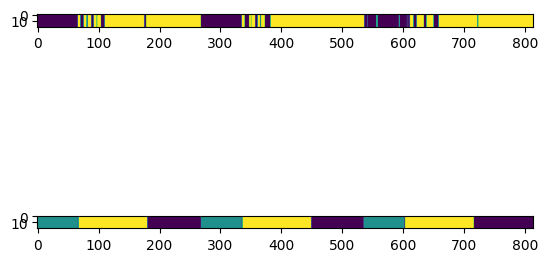

In [57]:
x_all = torch.tensor(bscan.T).float()
y_all = torch.tensor(wall_id).long()

with torch.no_grad():
    outputs = model(x_all).cpu().numpy()
    probs = outputs[:, 0]
fig, axes = plt.subplots(2, 1)
axes[0].imshow(probs.reshape(1, -1) * np.ones([20, len(probs)]), vmin=0, vmax=1)
axes[1].imshow(wall_id.reshape(1, -1) * np.ones([20, len(wall_id)]))